# Homework 3 - Simple Momentum Strategy

1. Download daily price data for QQQ, TLT, GLD, RWO from yahoo finance since 2016-01-01. Using the adjusted close price data, compute daily returns. This should be a DataFrame with index=date, columns=ticker and values=daily returns.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

In [2]:
tickers = ["QQQ", "TLT", "GLD", "RWO"]
data = yf.download(tickers, start="2016-01-01", auto_adjust=True)

[*********************100%***********************]  4 of 4 completed


In [3]:
returns = data['Close'].pct_change().dropna()

C:\Users\Nanda Kishor Girish\AppData\Local\Temp\ipykernel_12156\3351933747.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data['Close'].pct_change().dropna()


2. Compute the signal. Complete the compute_momentum function which computes a simple momentum signal. The function takes in a DataFrame with index = date, columns=ticker and values containing daily returns. It returns a new DataFrame with index = date, columns=ticker and values containing the momentum signal for the ticker on that day. The momentum signal for each ticker is defined as the annualized sharpe ratio of the past 252 days.

In [4]:
def compute_momentum(ret):

    # Calculate rolling mean and rolling standard deviation over a 252-day window
    rolling_mean = ret.rolling(window=252).mean()
    rolling_std = ret.rolling(window=252).std()

    # Calculate momentum as the ratio of rolling mean to rolling standard deviation
    momentum = (rolling_mean / rolling_std)*np.sqrt(252)

    return momentum

In [7]:
momentum_tickers = compute_momentum(returns).dropna()
momentum_tickers

Ticker,GLD,QQQ,RWO,TLT
Date,,,,
2017-01-03,0.520660,0.695790,0.412662,0.132060
2017-01-04,0.525030,0.740182,0.423392,0.193094
2017-01-05,0.531364,0.836453,0.511984,0.209561
2017-01-06,0.399179,1.107187,0.632195,0.124414
2017-01-09,0.477395,1.181900,0.683876,0.151565
...,...,...,...,...
2025-12-15,2.454387,0.734098,0.405407,-0.020486
2025-12-16,2.540670,0.769811,0.386460,0.124584
2025-12-17,2.653533,0.658066,0.410844,0.201838


3. Create a portfolio. Complete the function compute_portfolio. This function takes as input the DataFrame "momentum" from above. It returns a new DataFrame "portfolio" which has the same index/columns and has as values portfolio weights. The weights are computed as follows. On each date, equal-weight long the tickers with a momentum signal above 1.

In [ ]:
def grounding(number):
    if number > 1:
        return 1.0
    else:
        return 0.0


def compute_portfolio(momentum):
    portfolio = momentum.applymap(grounding)
    return portfolio

In [ ]:
portfolio = compute_portfolio(momentum_tickers)
portfolio

C:\Users\Nanda Kishor Girish\AppData\Local\Temp\ipykernel_12156\458724467.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  portfolio = momentum.applymap(grounding)


Ticker,GLD,QQQ,RWO,TLT
Date,,,,
2017-01-03,0.0,0.0,0.0,0.0
2017-01-04,0.0,0.0,0.0,0.0
2017-01-05,0.0,0.0,0.0,0.0
2017-01-06,0.0,1.0,0.0,0.0
2017-01-09,0.0,1.0,0.0,0.0
...,...,...,...,...
2025-12-15,1.0,0.0,0.0,0.0
2025-12-16,1.0,0.0,0.0,0.0
2025-12-17,1.0,0.0,0.0,0.0


4. Portfolio returns. Using the "portfolio" returned in part(3) and the returns generated in part(1), compute the returns to the simple momentum strategy. 
- What is the annualized sharpe ratio of the strategy? 
- How about the annualized sharpe ratio within each year? 
- How correlated is the strategy with the underlying tickers?
- Plot the cumulative sum of the returns through time

In [21]:
strat_ret = (portfolio.shift()*returns).sum(1)
# minor, but should start returns when signal starts
strat_ret = strat_ret.loc[momentum_tickers.dropna().index[0]:] 

In [24]:
sharp = strat_ret.mean() / strat_ret.std() * np.sqrt(252)

In [26]:
# sharpe within each year


sharpe = lambda x: x.mean()/x.std()*np.sqrt(252) 
strat_ret.groupby([x.year for x in strat_ret.index]).apply(sharpe)

2017    2.583499
2018    0.181242
2019    0.998783
2020    1.643772
2021    1.700939
2022   -1.014159
2023    0.803508
2024    1.354840
2025    2.488171
dtype: float64

In [28]:
# correlation
returns.corrwith(strat_ret)

Ticker
GLD    0.503636
QQQ    0.406521
RWO    0.251216
TLT    0.216078
dtype: float64

<Axes: xlabel='Date'>

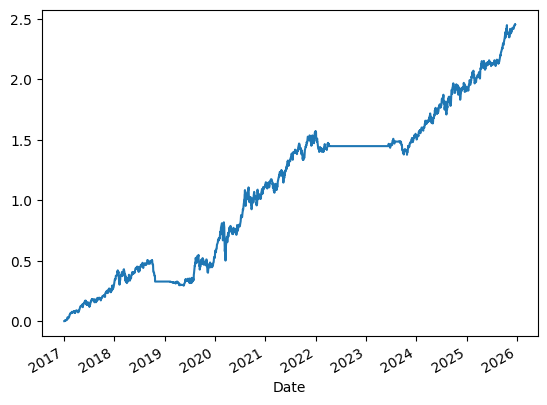

In [29]:
# cumulative returns
strat_ret.cumsum().plot()

In [30]:
portfolio.loc['2022-06-01':'2023-01-01']

Ticker,GLD,QQQ,RWO,TLT
Date,,,,
2022-06-01,0.0,0.0,0.0,0.0
2022-06-02,0.0,0.0,0.0,0.0
2022-06-03,0.0,0.0,0.0,0.0
2022-06-06,0.0,0.0,0.0,0.0
2022-06-07,0.0,0.0,0.0,0.0
...,...,...,...,...
2022-12-23,0.0,0.0,0.0,0.0
2022-12-27,0.0,0.0,0.0,0.0
2022-12-28,0.0,0.0,0.0,0.0
